In [1]:
# ── 3.0  IMPORTS ─────────────────────────────────────────────
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

In [3]:
# ── 3.1  LOAD DATA ────────────────────────────────────────────
print("=" * 60)
print("STEP 3 — MODEL 1: TF-IDF + LOGISTIC REGRESSION")
print("=" * 60)

df_train = pd.read_csv('../data/train.csv')
df_val   = pd.read_csv('../data/val.csv')
df_test  = pd.read_csv('../data/test.csv')

with open('../data/class_weights.json') as f:
    cw_dict = {int(k): v for k, v in json.load(f).items()}

X_train = df_train['combined_text'].fillna('').astype(str).values
y_train = df_train['label'].values
X_val   = df_val['combined_text'].fillna('').astype(str).values
y_val   = df_val['label'].values
X_test  = df_test['combined_text'].fillna('').astype(str).values
y_test  = df_test['label'].values

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

STEP 3 — MODEL 1: TF-IDF + LOGISTIC REGRESSION
Train: 8,000  Val: 1,000  Test: 1,000


In [5]:
# ── 3.3  BUILD PIPELINE ───────────────────────────────────────
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50_000,
        sublinear_tf=True,
        min_df=2,
        strip_accents='unicode'
    )),
    ('clf', LogisticRegression(
        solver='lbfgs',
        class_weight=cw_dict,
        random_state=RANDOM_STATE,
        max_iter=500
    ))
])

In [6]:
# ── 3.4  GRIDSEARCHCV ─────────────────────────────────────────
# DESIGN DECISION: We use 3-fold StratifiedKFold on the TRAINING set.
# n_jobs=1 avoids Windows/Jupyter multiprocessing deadlock.
# scoring='f1_macro' aligns hyperparameter search with our evaluation metric.

param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__sublinear_tf': [True, False],
    'clf__C': [0.1, 1.0, 5.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("Running GridSearchCV (12 combinations × 3 folds = 36 fits)...")
print("This searches the hyperparameter space to find the best configuration.")
print("Scoring: f1_macro (aligned with our primary evaluation metric)\n")

t0 = time.time()
grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=1, verbose=1, refit=True
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nGridSearchCV complete in {elapsed:.1f}s")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Macro F1: {grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_

Running GridSearchCV (12 combinations × 3 folds = 36 fits)...
This searches the hyperparameter space to find the best configuration.
Scoring: f1_macro (aligned with our primary evaluation metric)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearchCV complete in 45.4s
Best parameters: {'clf__C': 1.0, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Best CV Macro F1: 0.6648


In [7]:
# ── 3.5  VALIDATE ON VALIDATION SET ──────────────────────────
y_val_pred  = best_lr.predict(X_val)
val_macro_f1 = f1_score(y_val, y_val_pred, average='macro')
val_acc      = accuracy_score(y_val, y_val_pred)
print(f"\nValidation  Macro F1 : {val_macro_f1:.4f}")
print(f"Validation  Accuracy : {val_acc:.4f}")


Validation  Macro F1 : 0.6912
Validation  Accuracy : 0.8750


In [8]:
# ── 3.6  EVALUATE ON TEST SET ─────────────────────────────────
print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

y_pred  = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)

test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_acc      = accuracy_score(y_test, y_pred)
test_auc      = roc_auc_score(
    label_binarize(y_test, classes=[0,1,2]),
    y_proba, multi_class='ovr', average='macro'
)

print(f"\n  Macro F1  : {test_macro_f1:.4f}  ← PRIMARY METRIC")
print(f"  Accuracy  : {test_acc:.4f}  (misleading with 79.7% class imbalance)")
print(f"  ROC-AUC   : {test_auc:.4f}")
print("\nWhy Macro F1 and not Accuracy?")
print(f"  A trivial 'always predict Positive' classifier achieves")
majority_frac = (y_test == 2).mean()
print(f"  {majority_frac*100:.1f}% accuracy but Macro F1 ≈ 0.31")
print("  Macro F1 computes F1 per class then averages — every class")
print("  contributes equally regardless of size. This is the correct")
print("  metric when minority classes carry equal business value.")

print("\nClassification Report (per-class breakdown):")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


TEST SET EVALUATION

  Macro F1  : 0.6656  ← PRIMARY METRIC
  Accuracy  : 0.8700  (misleading with 79.7% class imbalance)
  ROC-AUC   : 0.9208

Why Macro F1 and not Accuracy?
  A trivial 'always predict Positive' classifier achieves
  79.9% accuracy but Macro F1 ≈ 0.31
  Macro F1 computes F1 per class then averages — every class
  contributes equally regardless of size. This is the correct
  metric when minority classes carry equal business value.

Classification Report (per-class breakdown):
              precision    recall  f1-score   support

    Negative       0.70      0.80      0.75       131
     Neutral       0.29      0.31      0.30        70
    Positive       0.96      0.93      0.94       799

    accuracy                           0.87      1000
   macro avg       0.65      0.68      0.67      1000
weighted avg       0.88      0.87      0.87      1000




INTERPRETABILITY — TOP DISCRIMINATING TOKENS PER CLASS
(coef_ matrix — each weight shows a token's class contribution)

  Negative — top 15 tokens:
    not                       +3.9633
    waste                     +2.6046
    one star                  +2.3273
    junk                      +2.2586
    two                       +2.1495
    useless                   +2.0583
    two stars                 +2.0384
    months                    +2.0005
    at all                    +1.8835
    doesn                     +1.8033
    poor                      +1.7594
    off                       +1.7557
    return                    +1.6696
    no                        +1.6673
    failed                    +1.6632

  Neutral — top 15 tokens:
    but                       +3.9414
    three stars               +3.6630
    ok                        +2.7670
    not                       +2.6569
    three                     +2.3867
    however                   +2.0388
    as                   

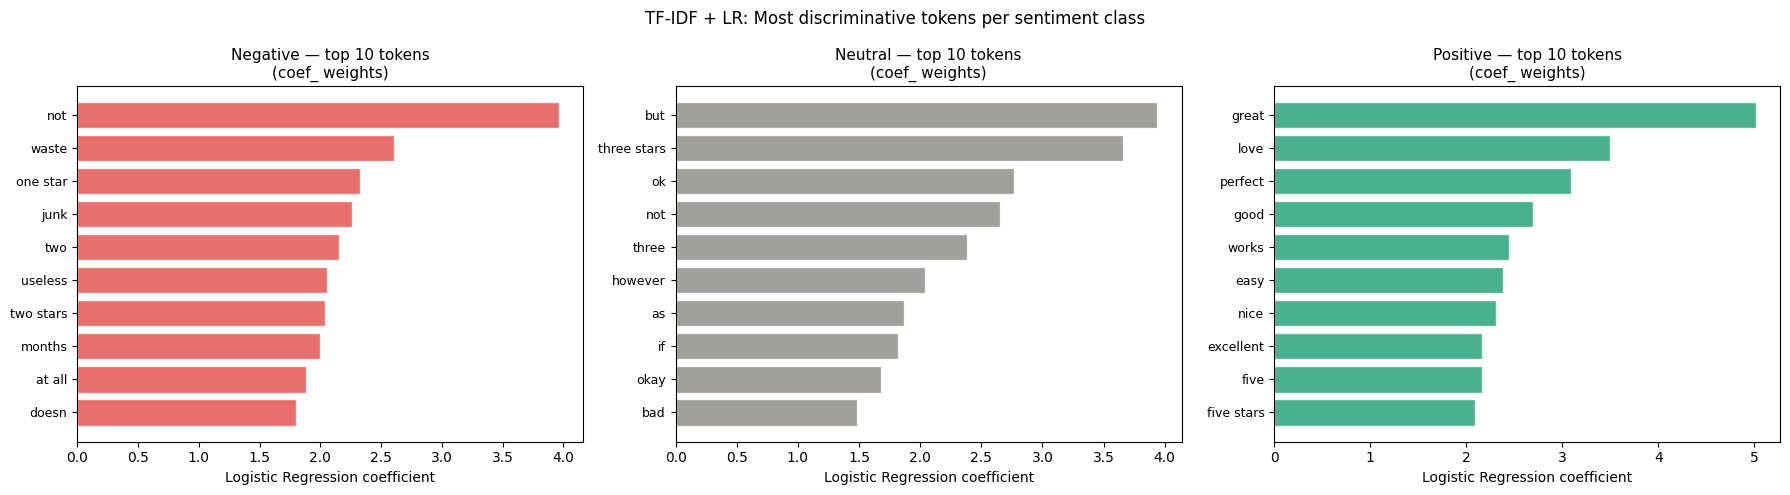


Saved: results/03_tfidf_lr_token_weights.png


In [9]:
# ── 3.7  INTERPRETABILITY — TOP TOKEN WEIGHTS ─────────────────
# This is unique to TF-IDF+LR — full audit trail of predictions.
# coef_ shape: (n_classes, n_features)
print("\n" + "=" * 60)
print("INTERPRETABILITY — TOP DISCRIMINATING TOKENS PER CLASS")
print("(coef_ matrix — each weight shows a token's class contribution)")
print("=" * 60)

feature_names = np.array(
    best_lr.named_steps['tfidf'].get_feature_names_out()
)
coef = best_lr.named_steps['clf'].coef_   # shape: (3, n_features)
TOP_N = 15

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    top_idx = np.argsort(coef[cls_idx])[-TOP_N:][::-1]
    top_tokens = feature_names[top_idx]
    top_weights = coef[cls_idx][top_idx]
    print(f"\n  {cls_name} — top {TOP_N} tokens:")
    for tok, w in zip(top_tokens, top_weights):
        print(f"    {tok:<25} {w:+.4f}")

# Plot top tokens per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#E24B4A', '#888780', '#1D9E75']

for cls_idx, (cls_name, col) in enumerate(zip(CLASS_NAMES, colors)):
    top_idx = np.argsort(coef[cls_idx])[-10:]
    tokens  = feature_names[top_idx]
    weights = coef[cls_idx][top_idx]

    axes[cls_idx].barh(range(10), weights, color=col, alpha=0.8, edgecolor='white')
    axes[cls_idx].set_yticks(range(10))
    axes[cls_idx].set_yticklabels(tokens, fontsize=9)
    axes[cls_idx].set_title(f'{cls_name} — top 10 tokens\n(coef_ weights)', fontsize=11)
    axes[cls_idx].set_xlabel('Logistic Regression coefficient')
    axes[cls_idx].axvline(0, color='black', linewidth=0.5)

plt.suptitle('TF-IDF + LR: Most discriminative tokens per sentiment class', fontsize=12)
plt.tight_layout()
plt.savefig('../results/03_tfidf_lr_token_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: results/03_tfidf_lr_token_weights.png")

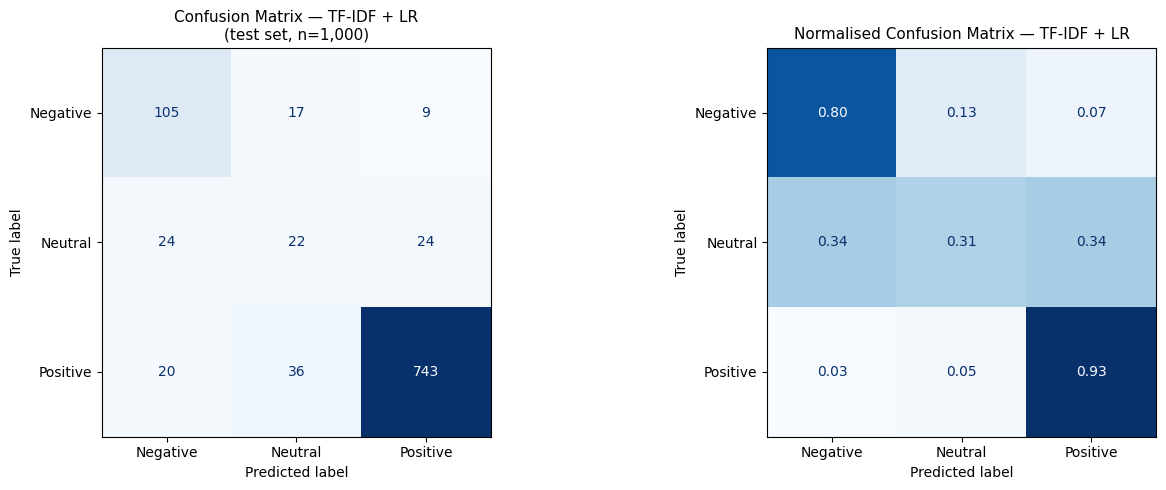


Dominant error mode: Positive → predicted as Neutral (36 cases)


In [11]:
# ── 3.8  CONFUSION MATRIX ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — TF-IDF + LR\n(test set, n=1,000)', fontsize=11)

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Normalised Confusion Matrix — TF-IDF + LR', fontsize=11)

plt.tight_layout()
plt.savefig('../results/03_tfidf_lr_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Analyse dominant error mode
off_diag = [(cm[i,j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(3) for j in range(3) if i!=j]
worst = max(off_diag)
print(f"\nDominant error mode: {worst[1]} → predicted as {worst[2]} ({worst[0]} cases)")


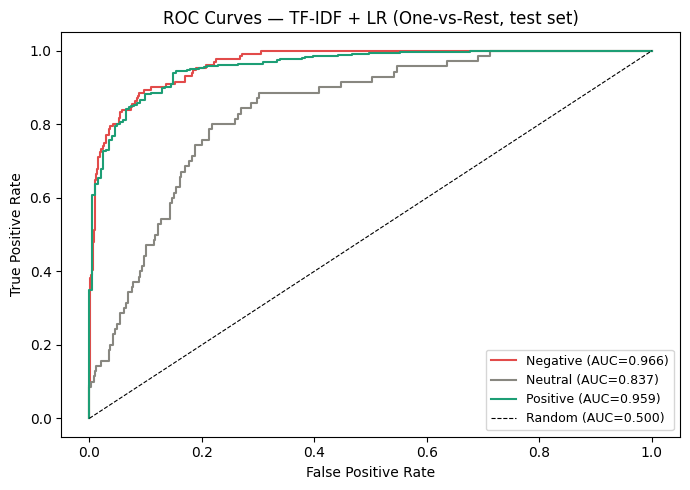

Saved: results/03_tfidf_lr_roc.png


In [12]:
# ── 3.9  ROC CURVES ───────────────────────────────────────────
y_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 5))
colors_roc = ['#E24B4A', '#888780', '#1D9E75']

for i, (cls_name, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc_i = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{cls_name} (AUC={roc_auc_i:.3f})')

ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — TF-IDF + LR (One-vs-Rest, test set)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/03_tfidf_lr_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/03_tfidf_lr_roc.png")

In [16]:
# ── 3.10  SAVE RESULTS ────────────────────────────────────────
results = {
    'model': 'TF-IDF + Logistic Regression',
    'macro_f1': round(test_macro_f1, 4),
    'accuracy': round(test_acc, 4),
    'roc_auc':  round(test_auc, 4),
    'best_params': grid_search.best_params_,
    'best_cv_f1': round(grid_search.best_score_, 4)
}
with open('../results/03_results_tfidf_lr.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "=" * 60)
print("MODEL 1 RESULTS SUMMARY")
print("=" * 60)
print(f"  Macro F1  : {test_macro_f1:.4f}  ← compare against DL models")
print(f"  Accuracy  : {test_acc:.4f}")
print(f"  ROC-AUC   : {test_auc:.4f}")
print("\nThis is the ML baseline.")
print(f"= {test_macro_f1:.4f} ")




MODEL 1 RESULTS SUMMARY
  Macro F1  : 0.6656  ← compare against DL models
  Accuracy  : 0.8700
  ROC-AUC   : 0.9208

This is the ML baseline.
= 0.6656 
